<a href="https://colab.research.google.com/github/shruuuuuug/Portfolio/blob/main/LandCoverClassificationProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Land Cover Classification & Change Detection of Dane Count**

# Initializing the GEE and the study area (Dane County)

In [ ]:
# ── Install packages
!pip install -q --upgrade earthengine-api gdown rasterio

import ee
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import rasterio, time, os
from rasterio.warp import reproject, Resampling
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             cohen_kappa_score, accuracy_score)
from sklearn.svm import SVC


# ── Authenticate & initialize GEE ──
ee.Authenticate()
ee.Initialize(project='sacred-buffer-489220-h9') # need to request permissions

# ── Mount Google Drive (for exporting/loading GeoTIFFs) ──
from google.colab import drive
drive.mount('/content/drive')

# ── Study area ──
madison_bbox = ee.Geometry.Rectangle([-89.8, 42.9, -89.0, 43.3])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# We initialize Earth Engine's Image Collection
hls = ee.ImageCollection("NASA/HLS/HLSL30/v002")

# Filter out 2015 and 2024 from June 1st to August 30th.
hls_2015 = hls.filterBounds(madison_bbox).filterDate('2015-06-01', '2015-08-30')
hls_2024 = hls.filterBounds(madison_bbox).filterDate('2024-06-01', '2024-08-30')

# Check scene counts
print("2015 Available Scenes:", hls_2015.size().getInfo())
print("2024 Available Scenes:", hls_2024.size().getInfo())

2015 Available Scenes: 33
2024 Available Scenes: 73


In [ ]:
# We make a function helps us mask out unwanted clouds, shadows, snow, and aerosol from the image
def mask_fmask(image):
    fmask = image.select('Fmask')

    cloud_mask = fmask.bitwiseAnd(1 << 1).eq(0)      # bit 1 = cloud
    shadow_mask = fmask.bitwiseAnd(1 << 3).eq(0)     # bit 3 = shadow
    snow_mask = fmask.bitwiseAnd(1 << 4).eq(0)       # bit 4 = snow/ice
    # bits 6 and 7 = high aerosol by gilang on 4/7
    aerosol_mask = fmask.bitwiseAnd(1 << 6).eq(0).Or(fmask.bitwiseAnd(1 << 7).eq(0)) #Changed to .Or because strong aerosol mask was resulting in empty composites

    # combine mask
    combined_mask = cloud_mask.And(shadow_mask).And(snow_mask).And(aerosol_mask)

    # sets the pixels in the image where the mask is "False" as transparent/invalid
    return image.updateMask(combined_mask)

In [ ]:
def process_image(image):
    blue  = image.select('B2')
    green = image.select('B3')
    red   = image.select('B4')
    nir   = image.select('B5')
    swir1 = image.select('B6')
    swir2 = image.select('B7')

    # EVI: 2.5 * (NIR - Red) / (NIR + 6*Red - 7.5*Blue + 1)
    denominator_evi = nir.add(red.multiply(6)).subtract(blue.multiply(7.5)).add(1)
    evi = ((nir.subtract(red)).multiply(2.5)).divide(denominator_evi).where(denominator_evi.eq(0), 0).rename('EVI') #handles divide by 0

    # SAVI: (NIR - Red) * 1.5 / (NIR + Red + 0.5)
    denominator_savi = nir.add(red).add(0.5)
    savi = nir.subtract(red).multiply(1.5).divide(denominator_savi).where(denominator_savi.eq(0), 0).rename('SAVI') #handles divide by 0

    ndvi  = image.normalizedDifference(['B5', 'B4']).rename('NDVI')
    ndwi  = image.normalizedDifference(['B3', 'B5']).rename('NDWI')
    ndbi  = image.normalizedDifference(['B6', 'B5']).rename('NDBI')
    mndwi = image.normalizedDifference(['B3', 'B6']).rename('MNDWI')

    # BSI: ((SWIR1 + Red) - (NIR + Blue)) / ((SWIR1 + Red) + (NIR + Blue))
    denominator_bsi = swir1.add(red).add(nir).add(blue)
    bsi = (swir1.add(red).subtract(nir.add(blue))).divide(denominator_bsi).where(denominator_bsi.eq(0), 0).rename('BSI') #handles divide by 0


    return image.addBands([ndvi, evi, savi, ndwi, mndwi, ndbi, bsi])

In [ ]:
feature_bands = ['NDVI', 'EVI', 'SAVI', 'NDWI', 'MNDWI', 'NDBI', 'BSI', 'B3', 'B4', 'B5', 'B6']

# apply masking to each map
hls_2015_masked = hls_2015.map(mask_fmask)
hls_2024_masked = hls_2024.map(mask_fmask)

# add the bands
hls_2015_processed = hls_2015_masked.map(process_image)
hls_2024_processed = hls_2024_masked.map(process_image)

composite_2015 = hls_2015_processed.select(feature_bands).median().clip(madison_bbox)
composite_2024 = hls_2024_processed.select(feature_bands).median().clip(madison_bbox)
composite_2015 = composite_2015.toFloat()
composite_2024 = composite_2024.toFloat()

What each band is:
* NDVI (Normalized Difference Vegetation Index): Measures vegetation greenness
* EVI (Enhanced Vegetation Index): Similar to NDVI but improves upon it by reducing atmospheric interference and background noise from soil
* SAVI (Soil Adjusted Vegetation Index): A modified NDVI that reduces the influence of soil brightness
* NDWI (Normalized Difference Water Index): Highlights open water bodies and water content in plants by using Green and NIR bands.
* MNDWI (Modified Normalized Difference Water Index): Uses Green and Shortwave Infrared (SWIR) bands to detect water bodies.
* NDBI (Normalized Difference Built-up Index): Uses SWIR and NIR bands to map urban areas
* BSI (Bare Soil Index): Combines blue, red, near-infrared, and shortwave infrared bands to map bare, exposed soil.

***don't need to run this code each session***

In [ ]:
task_2015 = ee.batch.Export.image.toDrive(
    image=composite_2015,
    description='HLS_2015',
    folder='GEE_Exports',
    fileNamePrefix='HLS_2015',
    scale=30,
    region=madison_bbox,
    crs='EPSG:32616',
    fileFormat='GeoTIFF'
)

task_2024 = ee.batch.Export.image.toDrive(
    image=composite_2024,
    description='HLS_2024',
    folder='GEE_Exports',
    fileNamePrefix='HLS_2024',
    scale=30,
    region=madison_bbox,
    crs='EPSG:32616',
    fileFormat='GeoTIFF'
)

task_2015.start()
task_2024.start()

# polling loop
print('Exporting HLS_2015 to Google Drive...')
while task_2015.active():
    time.sleep(5)
print('HLS_2015 export complete.')
print('HLS_2015 task status:', task_2015.status())

print('Exporting HLS_2024 to Google Drive...')
while task_2024.active():
    time.sleep(5)
print('HLS_2024 export complete.')
print('HLS_2024 task status:', task_2024.status())

print('All export tasks finished. Files should be in /content/drive/MyDrive/GEE_Exports/')

Exporting HLS_2015 to Google Drive...


KeyboardInterrupt: 

# Training Gaussian Naive Bayes, Decision Tree, Random Forest, and SVM (RBF)

In [ ]:
import os
for f in os.listdir("/content/drive/MyDrive/GEE_Exports"):
    print(f)

HLS_2015 (1).tif
HLS_2024 (1).tif
HLS_2015.tif
HLS_2024.tif


In [ ]:
# run this  to find the exact file paths:
folder = "/content/drive/MyDrive/Project 4 FWE458"
for f in os.listdir(folder):
    print(os.path.join(folder, f))

/content/drive/MyDrive/Project 4 FWE458/Final Project 4.ipynb
/content/drive/MyDrive/Project 4 FWE458/NLCD_2016_2024
/content/drive/MyDrive/Project 4 FWE458/Copy of HLS_2024.tif
/content/drive/MyDrive/Project 4 FWE458/Copy of HLS_2015.tif
/content/drive/MyDrive/Project 4 FWE458/Notes on project.gdoc
/content/drive/MyDrive/Project 4 FWE458/Group 3 Project 4.gslides


In [ ]:
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
import time

from rasterio.warp import reproject, Resampling
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                              cohen_kappa_score, accuracy_score,
                              ConfusionMatrixDisplay)

# Paths
HLS_2015_PATH  = "/content/drive/MyDrive/GEE_Exports/HLS_2015.tif"
HLS_2024_PATH  = "/content/drive/MyDrive/GEE_Exports/HLS_2024.tif"
NLCD_2015_PATH = '/content/drive/MyDrive/Project 4 FWE458/NLCD_2016_2024/Annual_NLCD_LndCov_2016_CU.tiff'
NLCD_2024_PATH = '/content/drive/MyDrive/Project 4 FWE458/NLCD_2016_2024/Annual_NLCD_LndCov_2024_CU.tiff'

# Verify files exist
import os
for p in [HLS_2015_PATH, HLS_2024_PATH, NLCD_2015_PATH, NLCD_2024_PATH]:
    status = "OK" if os.path.exists(p) else "NOT FOUND"
    print(f"  {status}: {p}")

  OK: /content/drive/MyDrive/GEE_Exports/HLS_2015.tif
  OK: /content/drive/MyDrive/GEE_Exports/HLS_2024.tif
  OK: /content/drive/MyDrive/Project 4 FWE458/NLCD_2016_2024/Annual_NLCD_LndCov_2016_CU.tiff
  OK: /content/drive/MyDrive/Project 4 FWE458/NLCD_2016_2024/Annual_NLCD_LndCov_2024_CU.tiff


In [ ]:
def load_hls(path):
    """Return (data array [bands, H, W], profile) for an HLS composite."""
    with rasterio.open(path) as src:
        data    = src.read().astype(np.float32)  # shape: (11, H, W)
        profile = src.profile.copy()
    return data, profile

def reproject_nlcd_to_hls(nlcd_path, hls_profile):
    """
    Reproject a NLCD raster onto the exact pixel grid of the HLS composite.
    Returns a 2-D uint8 array of NLCD class codes.
    """
    with rasterio.open(nlcd_path) as src:
        nlcd_src_crs       = src.crs
        nlcd_src_transform = src.transform
        nlcd_src_data      = src.read(1).astype(np.uint8)

    dst_shape = (hls_profile['height'], hls_profile['width'])
    nlcd_repr = np.zeros(dst_shape, dtype=np.uint8)

    reproject(
        source       = nlcd_src_data,
        destination  = nlcd_repr,
        src_transform= nlcd_src_transform,
        src_crs      = nlcd_src_crs,
        dst_transform= hls_profile['transform'],
        dst_crs      = hls_profile['crs'],
        resampling   = Resampling.nearest,
    )
    return nlcd_repr


hls_2015, profile_2015 = load_hls(HLS_2015_PATH)
hls_2024, profile_2024 = load_hls(HLS_2024_PATH)

nlcd_2015_raw = reproject_nlcd_to_hls(NLCD_2015_PATH, profile_2015)
nlcd_2024_raw = reproject_nlcd_to_hls(NLCD_2024_PATH, profile_2024)

print("HLS 2015 shape :", hls_2015.shape)
print("NLCD 2015 shape:", nlcd_2015_raw.shape)
print("Unique NLCD 2015 codes:", np.unique(nlcd_2015_raw))


HLS 2015 shape : (11, 1544, 2214)
NLCD 2015 shape: (1544, 2214)
Unique NLCD 2015 codes: [  0  11  21  22  23  24  31  41  42  43  52  71  81  82  90  95 250]


In [ ]:
NLCD_REMAP = {
    11: 1,              # Water
    21: 2, 22: 2, 23: 2, 24: 2,  # Urban
    41: 3, 42: 3, 43: 3,          # Forest
    52: 4, 71: 4,                  # Grassland/Shrub
    81: 5, 82: 5,                  # Cropland
    90: 6, 95: 6,                  # Wetland
}
CLASS_NAMES  = ['Water', 'Urban', 'Forest', 'Grassland/Shrub', 'Cropland', 'Wetland']
CLASS_LABELS = [1, 2, 3, 4, 5, 6]
CLASS_COLORS = ['#4575b4', '#d73027', '#1a9641', '#fee08b', '#fdae61', '#74add1']

def remap_nlcd(arr):
    out = np.zeros_like(arr, dtype=np.uint8)
    for src_code, dst_code in NLCD_REMAP.items():
        out[arr == src_code] = dst_code
    return out

nlcd_2015 = remap_nlcd(nlcd_2015_raw)
nlcd_2024 = remap_nlcd(nlcd_2024_raw)

print("Remapped NLCD 2015 classes:", np.unique(nlcd_2015))
print("Remapped NLCD 2024 classes:", np.unique(nlcd_2024))


Remapped NLCD 2015 classes: [0 1 2 3 4 5 6]
Remapped NLCD 2024 classes: [0 1 2 3 4 5 6]


In [ ]:
def build_pixel_table(hls_data, nlcd_data):
    """
    Converts HLS and NLCD raster data into a pixel table suitable for
    machine learning. Filters out pixels where NLCD is 0 (unclassified)
    and removes rows containing NaN values.

    Args:
        hls_data (np.ndarray): A 3D numpy array of HLS bands (bands, height, width).
        nlcd_data (np.ndarray): A 2D numpy array of NLCD class codes (height, width).

    Returns:
        tuple: A tuple containing:
            - X (np.ndarray): Feature matrix (pixels, bands).
            - y (np.ndarray): Label vector (pixels,).
            - valid_mask (np.ndarray): Boolean mask indicating valid pixels (pixels,).

    """
    # Flatten the HLS data: (bands, height, width) -> (height * width, bands)
    X_flat = hls_data.transpose(1, 2, 0).reshape(-1, hls_data.shape[0])

    # Flatten the NLCD data: (height, width) -> (height * width,)
    y_flat = nlcd_data.flatten()

    # Combined masks for shape restoration
    valid_mask = (y_flat > 0) & (~np.isnan(X_flat).any(axis=1))

    # Filter out pixels where NLCD class is 0 (unclassified/no data)
    valid_pixels_mask = (y_flat > 0)
    X_train = X_flat[valid_pixels_mask]
    y_train = y_flat[valid_pixels_mask]

    # Additionally, remove rows with NaN values from X_train
    # And apply the same mask to y_train
    nan_mask = ~np.isnan(X_train).any(axis=1)
    X_train = X_train[nan_mask]
    y_train = y_train[nan_mask]

    return X_train, y_train, valid_mask

# Step 10 with subsampling to prevent memory/time issues
X_train, y_train, valid_mask = build_pixel_table(hls_2015, nlcd_2015)
print(f"Total pixels: {len(y_train):,}")

# Subsample to 200,000 pixels max (still plenty for good accuracy)
MAX_PIXELS = 200000
if len(y_train) > MAX_PIXELS:
    rng = np.random.default_rng(42)
    idx = rng.choice(len(y_train), size=MAX_PIXELS, replace=False)
    X_train = X_train[idx]
    y_train = y_train[idx]
    print(f"Subsampled to: {len(y_train):,} pixels")

models = {
    'Naive Bayes':   GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100,  # reduced from 200
                                            n_jobs=-1,
                                            random_state=42)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, clf in models.items():
    all_true, all_pred = [], []
    oa_folds, kappa_folds = [], []
    t0 = time.time()
    print(f"  Training {name}...")

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_val)
        all_true.extend(y_val)
        all_pred.extend(y_pred)
        oa_folds.append(accuracy_score(y_val, y_pred))
        kappa_folds.append(cohen_kappa_score(y_val, y_pred))
        print(f"    Fold {fold+1}/5 done")

    #store decision tree model
    if name == 'Decision Tree':
        tree = clf
    if name == 'Random Forest':
        rf_model = clf #added by gilang 4/27


    elapsed = time.time() - t0
    cv_results[name] = {
        'y_true':      np.array(all_true),
        'y_pred':      np.array(all_pred),
        'oa_folds':    oa_folds,
        'kappa_folds': kappa_folds,
        'train_time':  elapsed,
    }
    oa_m  = np.mean(oa_folds)
    kap_m = np.mean(kappa_folds)
    print(f"  {name} done — OA={oa_m:.4f}  Kappa={kap_m:.4f}  Time={elapsed:.1f}s")

Total pixels: 1,640,298
Subsampled to: 200,000 pixels
  Training Naive Bayes...
    Fold 1/5 done
    Fold 2/5 done
    Fold 3/5 done
    Fold 4/5 done
    Fold 5/5 done
  Naive Bayes done — OA=0.6066  Kappa=0.4705  Time=0.5s
  Training Decision Tree...
    Fold 1/5 done
    Fold 2/5 done
    Fold 3/5 done
    Fold 4/5 done
    Fold 5/5 done
  Decision Tree done — OA=0.7879  Kappa=0.6672  Time=18.7s
  Training Random Forest...
    Fold 1/5 done
    Fold 2/5 done
    Fold 3/5 done
    Fold 4/5 done
    Fold 5/5 done
  Random Forest done — OA=0.8044  Kappa=0.6952  Time=472.9s


In [ ]:

# create copies of X_train and y_train for SVM-specific subsampling
X_train_svm = X_train.copy()
y_train_svm = y_train.copy()

# Subsample to 100,000 pixels max for only the SVM
MAX_PIXELS_SVM = 100000
if len(y_train_svm) > MAX_PIXELS_SVM:
    rng_svm = np.random.default_rng(42)
    idx_svm = rng_svm.choice(len(y_train_svm), size=MAX_PIXELS_SVM, replace=False)
    X_train_svm = X_train_svm[idx_svm]
    y_train_svm = y_train_svm[idx_svm]
    print(f"Subsampled for SVM to: {len(y_train_svm):,} pixels")
else:
    print(f"SVM using existing {len(y_train_svm):,} pixels (no further subsampling needed).")

models_svm = {
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42) # Define SVM model
}

# Add SVM results to the existing cv_results.

for name, clf in models_svm.items():
    all_true, all_pred = [], []
    oa_folds, kappa_folds = [], []
    t0 = time.time()
    print(f"  Training {name}...")

    # Use the SVM-specific subsampled data for training
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_svm, y_train_svm)):
        X_tr, X_val = X_train_svm[tr_idx], X_train_svm[val_idx]
        y_tr, y_val = y_train_svm[tr_idx], y_train_svm[val_idx]
        clf.fit(X_tr, y_tr)
        y_pred = clf.predict(X_val)
        all_true.extend(y_val)
        all_pred.extend(y_pred)
        oa_folds.append(accuracy_score(y_val, y_pred))
        kappa_folds.append(cohen_kappa_score(y_val, y_pred))
        print(f"    Fold {fold+1}/5 done")

    if name == 'SVM (RBF)':
        svm_model = clf # Store the trained SVM model

    elapsed = time.time() - t0
    cv_results[name] = { # Add results to the globally available cv_results
        'y_true':      np.array(all_true),
        'y_pred':      np.array(all_pred),
        'oa_folds':    oa_folds,
        'kappa_folds': kappa_folds,
        'train_time':  elapsed,
    }
    oa_m  = np.mean(oa_folds)
    kap_m = np.mean(kappa_folds)
    print(f"  {name} done — OA={oa_m:.4f}  Kappa={kap_m:.4f}  Time={elapsed:.1f}s")

Subsampled for SVM to: 100,000 pixels
  Training SVM (RBF)...
    Fold 1/5 done
    Fold 2/5 done
    Fold 3/5 done
    Fold 4/5 done
    Fold 5/5 done
  SVM (RBF) done — OA=0.7808  Kappa=0.6472  Time=1249.2s


In [ ]:
# STEP 11: Accuracy assessment summary table

# Bonus (+5 pts)
# Add a 4th model — Support Vector Machine (SVM with RBF kernel) — to the comparison.
# Report its accuracy, discuss performance relative to the other three, and
# consider computational cost.

rows = []
for name, res in cv_results.items():
    rows.append({
        'Model':       name,
        'OA (mean)':   np.mean(res['oa_folds']),
        'OA (std)':    np.std(res['oa_folds']),
        'Kappa (mean)':np.mean(res['kappa_folds']),
        'Kappa (std)': np.std(res['kappa_folds']),
        'Train time (s)': res['train_time'],
    })
summary_df = pd.DataFrame(rows).set_index('Model')
print("\n── Accuracy Summary ──")
print(summary_df.round(4))


── Accuracy Summary ──
               OA (mean)  OA (std)  Kappa (mean)  Kappa (std)  Train time (s)
Model                                                                        
Naive Bayes       0.6066    0.0025        0.4705       0.0027          0.5345
Decision Tree     0.7879    0.0016        0.6672       0.0019         18.7497
Random Forest     0.8044    0.0013        0.6952       0.0019        472.9032
SVM (RBF)         0.7808    0.0013        0.6472       0.0020       1249.2242


***Even though SVM had half the sub-sample size, it still took the longest to run compared to the random forest. Deciison tree and random forest are also similar in OA and Kappa, implying that one tree is enough to analyze the HLS***


* Apply the best model (trained on all NLCD 2015 + HLS 2015 data) to both the 2015 and 2024 composites. Reshape predictions back to 2D map arrays.
* Compare 2024 classified map against NLCD 2024.
* Compare the 2015 and 2024 classified maps. Count changed pixels, compute the area in hectares (30 m × 30 m = 900 m² per pixel), and build a transition matrix of the top land cover transitions.


In [ ]:
# save shape
n_bands2015, height, width = hls_2015.shape
# Flatten the HLS data: (bands, height, width) -> (height * width, bands)
X_test_2015, y_test_2015, valid_mask = build_pixel_table(hls_2015, nlcd_2015)
# predict
pred_2015 = tree.predict(X_test_2015)

# restore 2d using mask to complete shape
flatmap_2015 = np.full((height * width), 0, dtype=np.int16)
flatmap_2015[valid_mask] = pred_2015

# Reshape to 2D
map_2015 = flatmap_2015.reshape(height, width)

print(f"Final 2D Map Shape: {map_2015.shape}")

## Repeat for 2024

n_height, n_width = nlcd_2024.shape
n_bands2024, height, width = hls_2024.shape
X_test_2024, y_test_2024, valid_mask = build_pixel_table(hls_2024, nlcd_2024)

pred_2024 = tree.predict(X_test_2024)

flatmap_2024 = np.full((height * width), 0, dtype=np.int16)
flatmap_2024[valid_mask] = pred_2024

# Reshape to 2D
map_2024 = flatmap_2024.reshape(height, width)

print(f"Final 2D Map Shape: {map_2024.shape}")

Final 2D Map Shape: (1544, 2214)
Final 2D Map Shape: (1544, 2214)


In [ ]:
oa_2024 = accuracy_score(nlcd_2024.flatten(), map_2024.flatten())
kappa_2024 = cohen_kappa_score(nlcd_2024.flatten(), map_2024.flatten())
print(f"Overall Accuracy: {oa_2024:.4f}")
print(f"Kappa: {kappa_2024:.4f}")


Overall Accuracy: 0.8714
Kappa: 0.8023


In [ ]:
# Changed pixels
changed_pixels = np.sum(map_2015 != map_2024)
print(f'Total changed pixels: {changed_pixels}')

# in hectares
changed_area_hect = changed_pixels * .09
print(f'Total changed area (ha): {changed_area_hect}')

# transition matrix

class_dict = dict(zip(CLASS_LABELS, CLASS_NAMES))
transition_df = pd.DataFrame({'2015': map_2015.flatten(), '2024': map_2024.flatten()})
transition_matrix = transition_df.groupby(['2015', '2024']).size().unstack(fill_value=0)
transition_matrix.index = transition_matrix.index.map(class_dict)
transition_matrix.columns = transition_matrix.columns.map(class_dict)
transition_matrix = transition_matrix.reindex(index=CLASS_NAMES, columns=CLASS_NAMES, fill_value=0)

#covert pixels to hectares
pixels_to_ha = 0.09
ha_transition_matrix = transition_matrix * pixels_to_ha
ha_transition_matrix = ha_transition_matrix.style.format("{:.2f}").set_caption("Transition Matrix (ha)")


# find top changes

trans_data = ha_transition_matrix.data
top_changes = trans_data.stack().sort_values(ascending=False)
top_changes = top_changes[top_changes.index.get_level_values(0) != top_changes.index.get_level_values(1)]
top_changes = top_changes.head(10)
top_changes_df = top_changes.reset_index()
top_changes_df.columns = ['2015', '2024', 'Hectares']
top_changes_df = top_changes_df.style.format({'Hectares': '{:.2f}'}).set_caption("Top Land Cover Changes (ha)")

display(ha_transition_matrix)
print(' ' * 30)
display(top_changes_df)


Total changed pixels: 391966
Total changed area (ha): 35276.94


2024,Water,Urban,Forest,Grassland/Shrub,Cropland,Wetland
2015,,,,,,
Water,8111.88,72.27,4.14,3.33,42.39,97.92
Urban,109.44,31762.62,623.88,0.63,3311.10,1689.39
Forest,9.18,1667.16,8046.36,0.00,1136.97,614.07
Grassland/Shrub,3.42,2.25,0.18,0.18,7.74,2.16
Cropland,107.19,12851.64,1991.88,8.82,63266.13,4090.86
Wetland,178.02,1741.32,471.33,1.17,2171.07,1651.50


,2015,2024,Hectares
0,Cropland,Urban,12851.64
1,Cropland,Wetland,4090.86
2,Urban,Cropland,3311.10
3,Wetland,Cropland,2171.07
4,Cropland,Forest,1991.88
5,Wetland,Urban,1741.32
6,Urban,Wetland,1689.39
7,Forest,Urban,1667.16
8,Forest,Cropland,1136.97
9,Urban,Forest,623.88


Figure 1: True-color RGB composites — 2015 and 2024 side by side

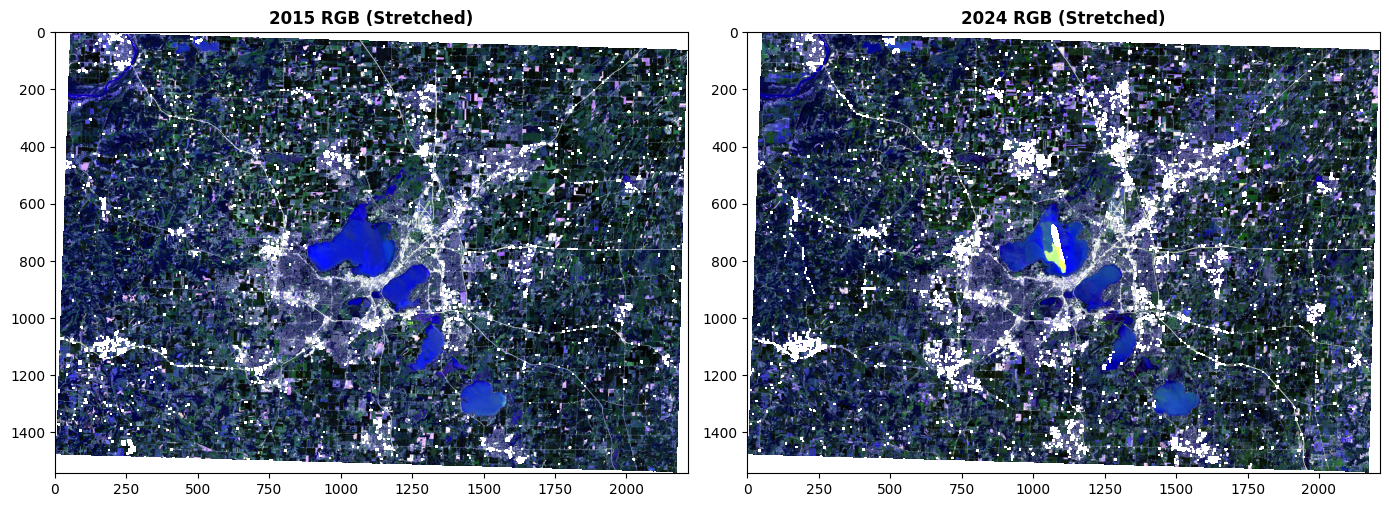

In [ ]:
#P5F1 V2
import numpy as np
import matplotlib.pyplot as plt
from rasterio.plot import show
plt.rcParams['image.cmap'] = 'viridis'
comp2015 = rasterio.open("/content/drive/MyDrive/GEE_Exports/HLS_2015.tif")
comp2024 = rasterio.open("/content/drive/MyDrive/GEE_Exports/HLS_2024.tif") #accesses composited from p2

def stretch(band): #basicaly j a functoin to reduce contrast by clipping super light and super dark values while keeping things between 0 and 1
    p2, p98 = np.nanpercentile(band, (2, 98))
    band = np.clip((band - p2) / (p98 - p2), 0, 1)
    return band

def build_rgb_stretched(ds):
    red   = stretch(ds.read(9).astype(float))
    green = stretch(ds.read(8).astype(float))
    blue  = stretch(ds.read(7).astype(float))  #BSI fallback. Blue substitute

    rgb = np.stack([red, green, blue], axis=0) #stacks the 3 colorways into RGB image
    return rgb

rgb2015 = build_rgb_stretched(comp2015)
rgb2024 = build_rgb_stretched(comp2024)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
show(rgb2015, ax=axes[0], title="2015 RGB (Stretched)")
show(rgb2024, ax=axes[1], title="2024 RGB (Stretched)")
plt.tight_layout()
plt.show()


Figure 2: Confusion matrix comparison — all 3 models in one row (normalized). OA and Kappa labeled on each.



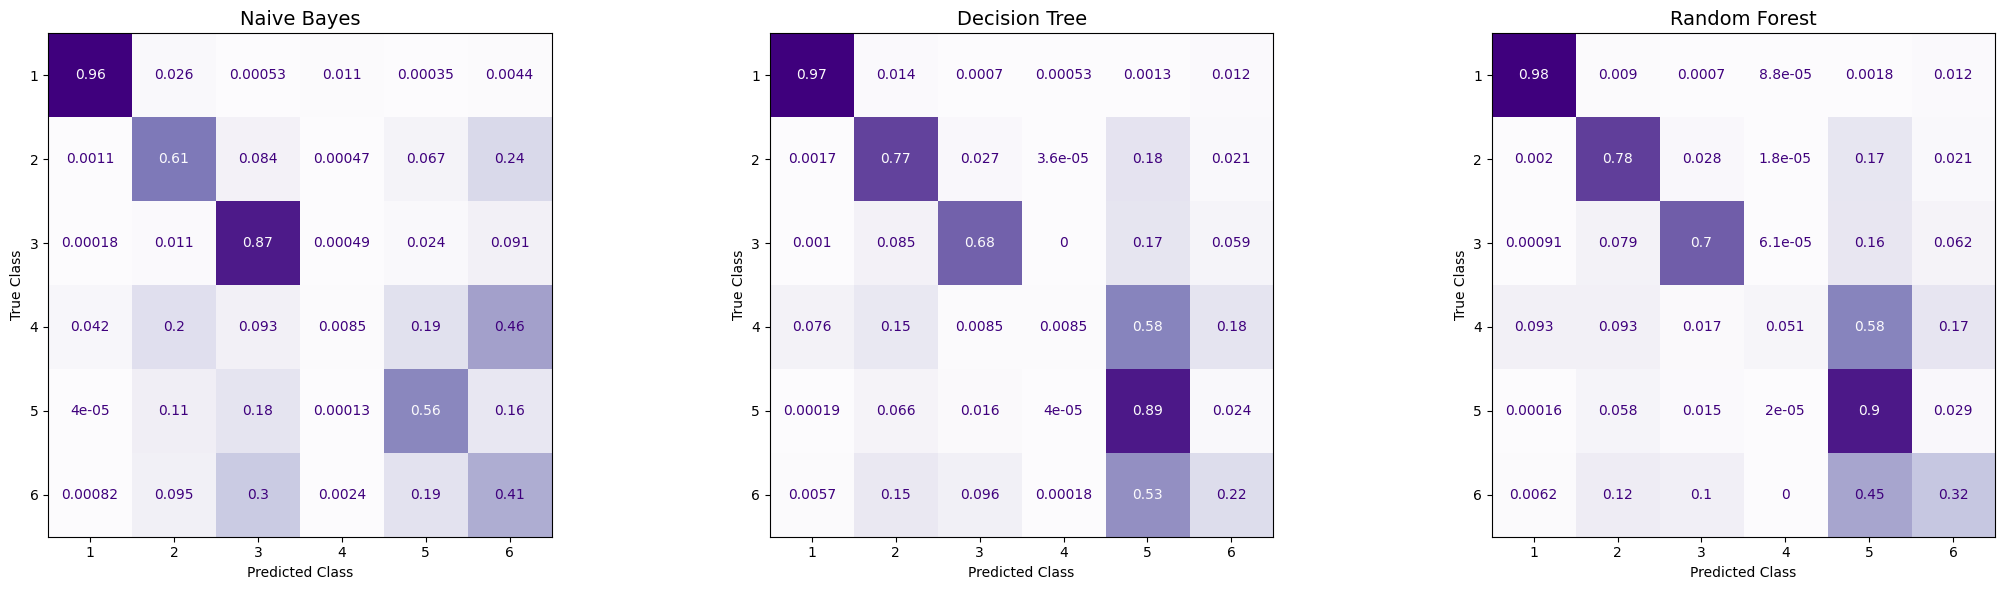

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Extract predictions from cv_results
y_true_nb = cv_results['Naive Bayes']['y_true']
y_pred_nb = cv_results['Naive Bayes']['y_pred']

y_true_dt = cv_results['Decision Tree']['y_true']
y_pred_dt = cv_results['Decision Tree']['y_pred']

y_true_rf = cv_results['Random Forest']['y_true']
y_pred_rf = cv_results['Random Forest']['y_pred']

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

model_outputs = [
    ("Naive Bayes", y_true_nb, y_pred_nb),
    ("Decision Tree", y_true_dt, y_pred_dt),
    ("Random Forest", y_true_rf, y_pred_rf)
]

for ax, (title, y_t, y_p) in zip(axes, model_outputs): #for each model, plots NORMALIZED confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_t,
        y_p,
        normalize="true",
        cmap="Purples",
        ax=ax,
        colorbar=False
    )
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("True Class")

plt.tight_layout()
plt.show()


Figure 3: Model accuracy comparison bar chart — OA and Kappa for all 3 models.



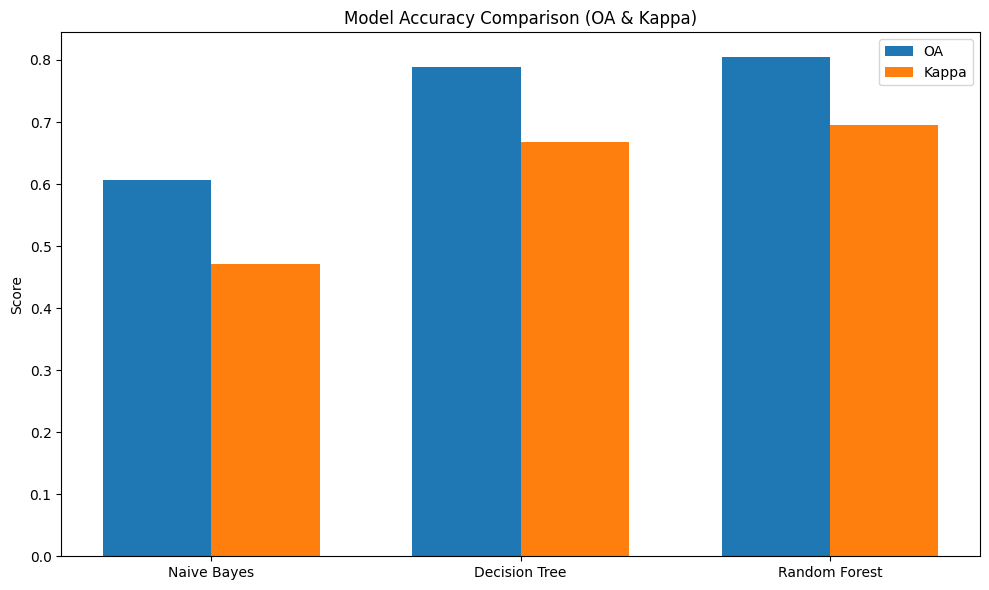

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

models = ["Naive Bayes", "Decision Tree", "Random Forest"]

#computes overall accuracy and kappa (How much better is our agreement than just random guessing?)
oa_scores = [
    np.mean(cv_results['Naive Bayes']['oa_folds']),
    np.mean(cv_results['Decision Tree']['oa_folds']),
    np.mean(cv_results['Random Forest']['oa_folds'])
]

kappa_scores = [
    np.mean(cv_results['Naive Bayes']['kappa_folds']),
    np.mean(cv_results['Decision Tree']['kappa_folds']),
    np.mean(cv_results['Random Forest']['kappa_folds'])
]

x = np.arange(len(models))
width = 0.35
#create barchart
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, oa_scores, width, label="OA")
ax.bar(x + width/2, kappa_scores, width, label="Kappa")

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("Score")
ax.set_title("Model Accuracy Comparison (OA & Kappa)")
ax.legend()

plt.tight_layout()
plt.show()


Figure 4: Decision Tree structure visualization — top 4 levels, nodes colored by class.



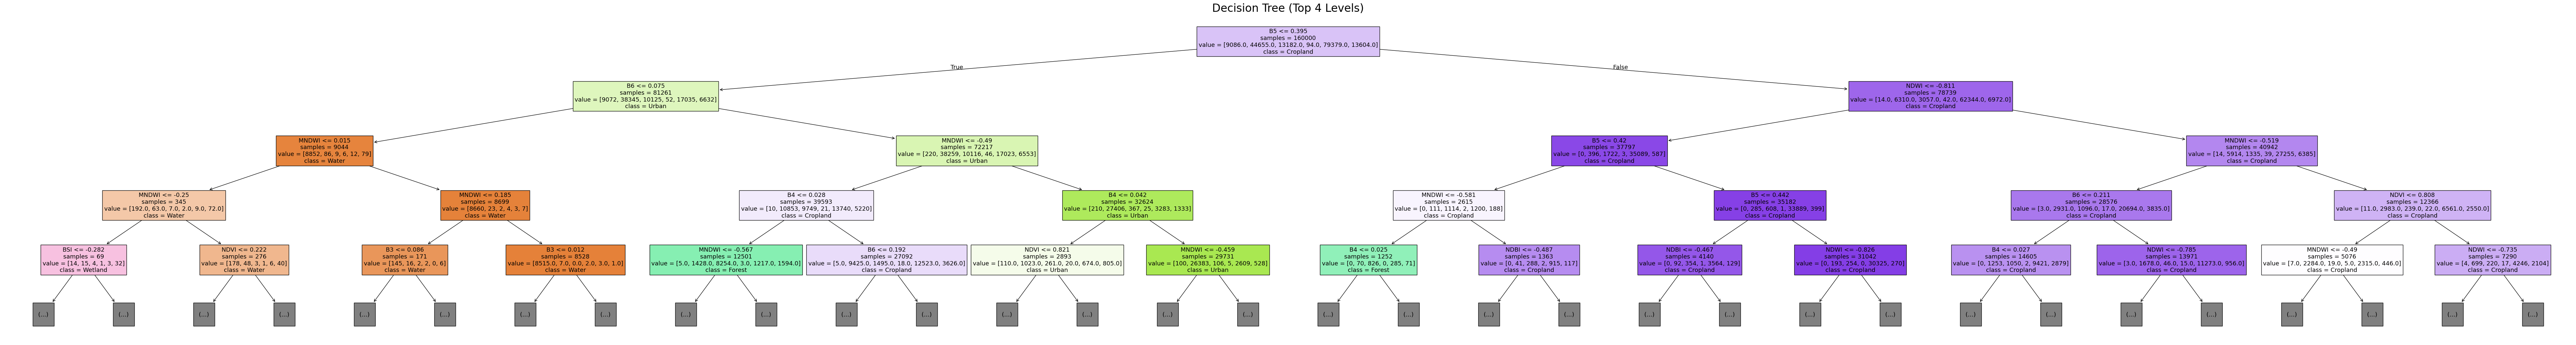

In [ ]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

#makes giant figure to accomodate for text. before it was smushed/overlapping
plt.figure(figsize=(80, 20))

#trains a final Decision Tree model on all training data
plot_tree(
    tree,
    max_depth=4,
    feature_names=feature_bands,
    class_names=CLASS_NAMES,
    filled=True, #paints nodes based on class
    impurity=False, #we don't care much for impurity
    fontsize=13
)

plt.title("Decision Tree (Top 4 Levels)", fontsize=24)
plt.subplots_adjust(left=0.01, right=0.99, top=0.50, bottom=0.0002) #further prevents smushing of text @ bottom
plt.show()

Figure 5: Feature importance comparison — RF vs. Decision Tree (side-by-side bar charts).



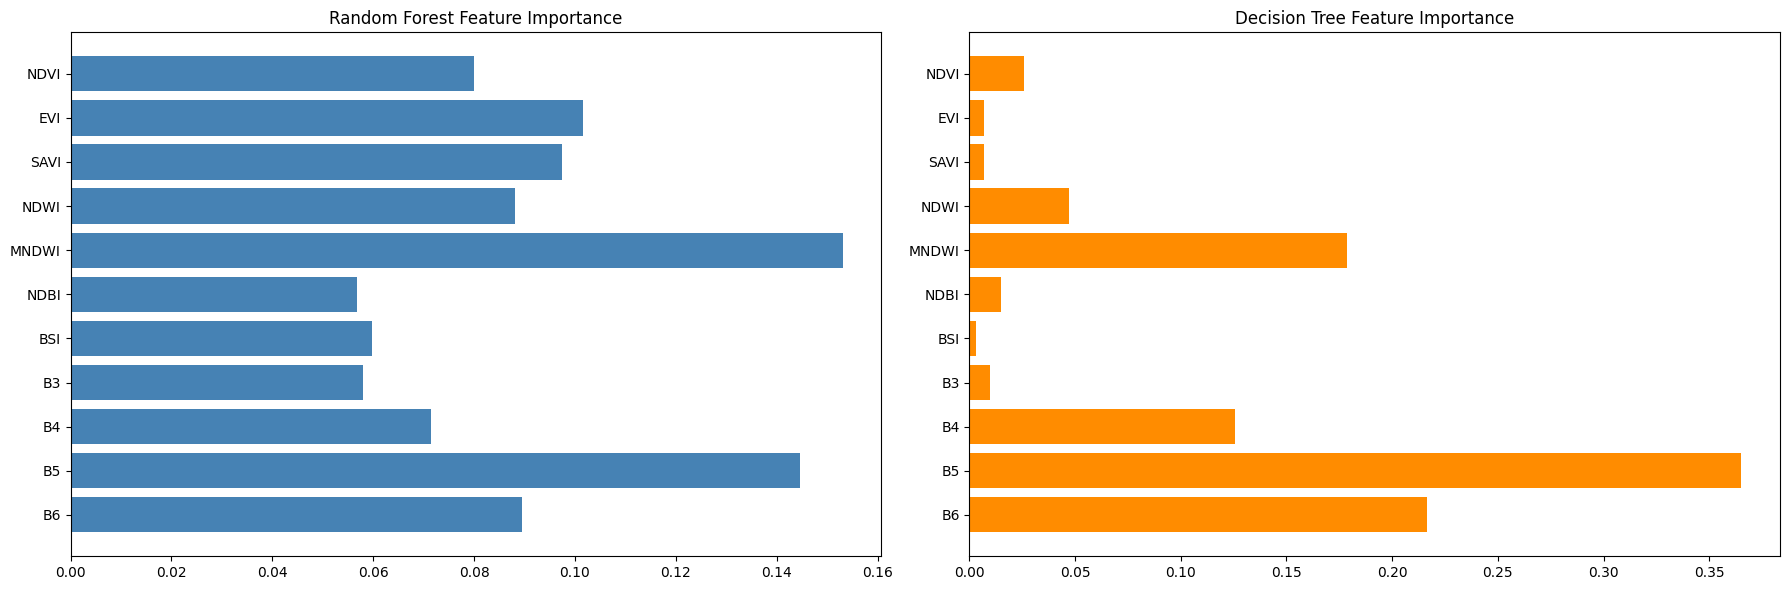

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#gets feature importance scores to see which spectral bands most important
rf_importance = rf_model.feature_importances_
dt_importance = tree.feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

#random forest
axes[0].barh(feature_bands, rf_importance, color="steelblue")
axes[0].set_title("Random Forest Feature Importance")
axes[0].invert_yaxis()

#decision tree
axes[1].barh(feature_bands, dt_importance, color="darkorange")
axes[1].set_title("Decision Tree Feature Importance")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


Figure 6: Model agreement map — how many of the 3 classifiers agree per pixel.



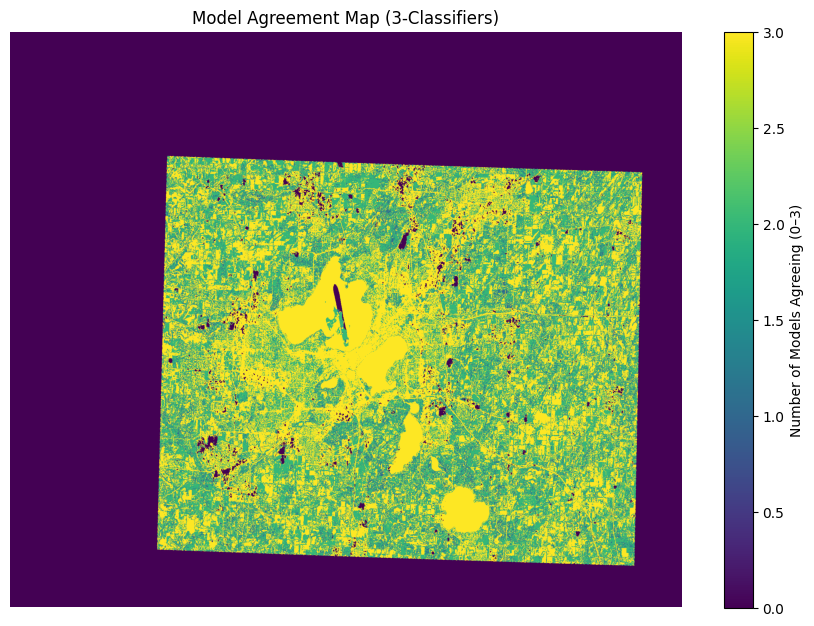

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['image.cmap'] = 'viridis'

#pixel table for 2024 (features only)
X_2024, y_2024, valid_mask = build_pixel_table(hls_2024, nlcd_2024)

#predictions from all 3 models
pred_dt = tree.predict(X_2024)
pred_rf = rf_model.predict(X_2024)
pred_nb = GaussianNB().fit(X_train, y_train).predict(X_2024)
pred_stack = np.vstack([pred_dt, pred_rf, pred_nb])  # shape: (3, N)

#count agreement per pixel
agreement = np.sum(pred_stack == pred_stack[0], axis=0)

#reconstructs agreement values into 2D map
agree_map = np.full((hls_2024.shape[1] * hls_2024.shape[2]), 0)
agree_map[valid_mask] = agreement
agree_map = agree_map.reshape(hls_2024.shape[1], hls_2024.shape[2])

#plot
plt.figure(figsize=(10, 6))
plt.imshow(agree_map, cmap="viridis", aspect='auto')
plt.colorbar(label="Number of Models Agreeing (0–3)")
plt.title("Model Agreement Map (3-Classifiers)")
plt.axis("off")
plt.subplots_adjust(left=0.01, right=0.85, top=0.98, bottom=0.02)
plt.show()


Figure 7: Land cover map (best model, 2024) with discrete colormap and legend.



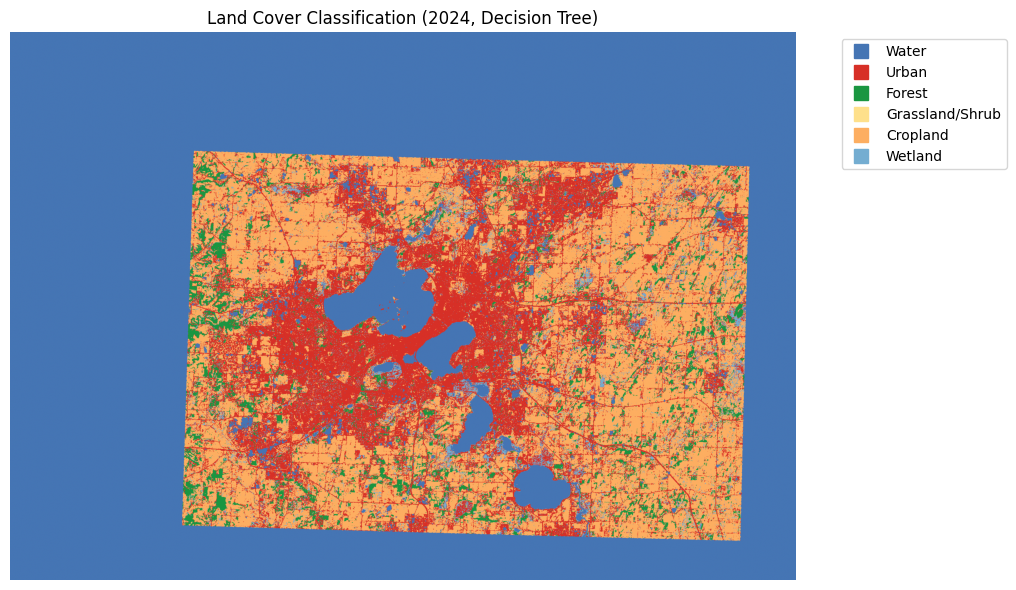

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

#create discrete colormap
cmap = mcolors.ListedColormap(CLASS_COLORS)
bounds = np.arange(1, 8)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

#plot land types
plt.figure(figsize=(10, 6))
plt.imshow(map_2024, cmap=cmap, norm=norm)
plt.title("Land Cover Classification (2024, Decision Tree)")
plt.axis("off")

#legend
patches = [plt.plot([],[], marker="s", ms=10, ls="",
                    color=CLASS_COLORS[i])[0] for i in range(6)]
plt.legend(patches, CLASS_NAMES, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


Figure 8: Change detection map with area comparison bar chart (2015 vs. 2024).


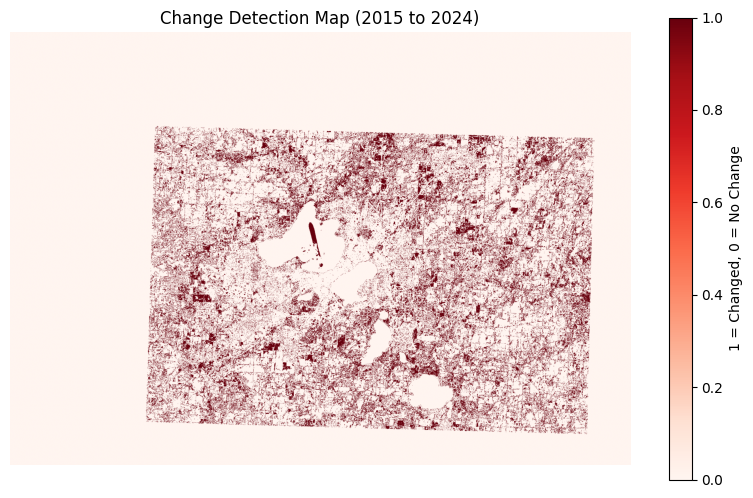

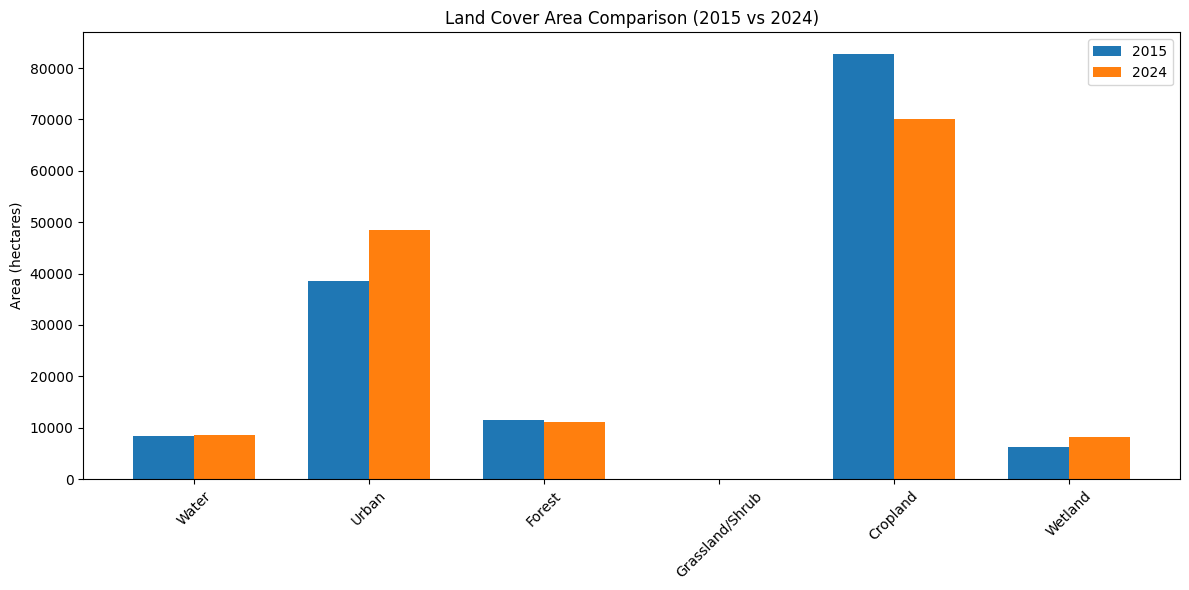

In [ ]:
change_map = (map_2015 != map_2024).astype(int)

plt.figure(figsize=(10, 6))
plt.imshow(change_map, cmap="Reds")
plt.title("Change Detection Map (2015 to 2024)")
plt.colorbar(label="1 = Changed, 0 = No Change")
plt.axis("off")
plt.show()

#count pixels per class
counts_2015 = [np.sum(map_2015 == c) for c in CLASS_LABELS]
counts_2024 = [np.sum(map_2024 == c) for c in CLASS_LABELS]

#convert to hectares
area_2015 = np.array(counts_2015) * 0.09
area_2024 = np.array(counts_2024) * 0.09

x = np.arange(len(CLASS_NAMES))
width = 0.35


plt.figure(figsize=(12, 6))
plt.bar(x - width/2, area_2015, width, label="2015")
plt.bar(x + width/2, area_2024, width, label="2024")

#plots a bar chart comparing class areas across years
plt.xticks(x, CLASS_NAMES, rotation=45)
plt.ylabel("Area (hectares)")
plt.title("Land Cover Area Comparison (2015 vs 2024)")
plt.legend()
plt.tight_layout()
plt.show()
